In [ ]:
import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
import torch.backends.cudnn as cudnn
from torchmetrics.functional.image import peak_signal_noise_ratio as psnr
from torchmetrics.image import StructuralSimilarityIndexMeasure as SSIM
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
cudnn.benchmark = True
print("Using device:", device)

Using device: cuda:0


In [4]:
class NPYDataset(Dataset):
    def __init__(self, lr_dir, hr_dir, out_res):
        self.lr_files = sorted(glob(os.path.join(lr_dir, "*.npy")))
        self.hr_files = sorted(glob(os.path.join(hr_dir, "*.npy")))

        if len(self.lr_files) == 0 or len(self.hr_files) == 0:
            raise FileNotFoundError("No .npy files found in the provided directories!")

        if len(self.lr_files) != len(self.hr_files):
            raise ValueError(f"Mismatch in LR and HR files: {len(self.lr_files)} vs {len(self.hr_files)}")

        self.out_res = out_res

    def __len__(self):
        return len(self.lr_files)

    def __getitem__(self, index):
        lr = np.load(self.lr_files[index])
        hr = np.load(self.hr_files[index])

        if lr.shape != (1, 75, 75) and lr.shape != (1, 64, 64):
            raise ValueError(f"Unexpected LR shape {lr.shape}")
        if hr.shape != (1, 150, 150) and hr.shape != (1, 128, 128):
            raise ValueError(f"Unexpected HR shape {hr.shape}")

        lr_resized = cv2.resize(lr[0], (self.out_res, self.out_res), interpolation=cv2.INTER_CUBIC)
        lr_resized = lr_resized[np.newaxis, :, :]

        lr_tensor = torch.tensor(lr_resized, dtype=torch.float32)
        hr_tensor = torch.tensor(hr, dtype=torch.float32)

        return lr_tensor, hr_tensor

In [5]:
class ChannelAttention(nn.Module):
    def __init__(self, num_features, reduction):
        super().__init__()
        self.module = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(num_features, num_features // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features // reduction, num_features, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.module(x)


class RCAB(nn.Module):
    def __init__(self, num_features, reduction):
        super().__init__()
        self.module = nn.Sequential(
            nn.Conv2d(num_features, num_features, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features, num_features, 3, padding=1),
            ChannelAttention(num_features, reduction)
        )

    def forward(self, x):
        return x + self.module(x)


class RG(nn.Module):
    def __init__(self, num_features, num_rcab, reduction):
        super().__init__()
        layers = [RCAB(num_features, reduction) for _ in range(num_rcab)]
        layers.append(nn.Conv2d(num_features, num_features, 3, padding=1))
        self.module = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.module(x)


In [6]:
class RCAN(nn.Module):
    def __init__(self, args):
        super().__init__()
        self.out_res = args['out_res']
        num_features = args['num_features']
        num_rg = args['num_rg']
        num_rcab = args['num_rcab']
        reduction = args['reduction']

        self.sf = nn.Conv2d(1, num_features, 3, padding=1)
        self.rgs = nn.Sequential(*[RG(num_features, num_rcab, reduction) for _ in range(num_rg)])
        self.conv1 = nn.Conv2d(num_features, num_features, 3, padding=1)

        self.upscale = nn.Sequential(
            nn.Conv2d(num_features, num_features, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(num_features, num_features, 4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_features, num_features, 3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.upsample = nn.Upsample(size=(self.out_res, self.out_res), mode='bicubic', align_corners=False)
        self.conv2 = nn.Conv2d(num_features, 1, 3, padding=1)

    def forward(self, x):
        x = self.sf(x)
        res = x
        x = self.rgs(x)
        x = self.conv1(x)
        x += res
        x = self.upscale(x)
        x = self.upsample(x)
        x = self.conv2(x)
        return x

In [7]:
class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = self.avg = self.sum = self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [7]:
# Define your configuration
config = {
    'lr_dir': '/teamspace/studios/this_studio/Dataset/LR',
    'hr_dir': '/teamspace/studios/this_studio/Dataset/HR',  
    'outputs_dir': './checkpoints',
    'out_res': 150,
    'num_features': 64,
    'num_rg': 10,
    'num_rcab': 20,
    'reduction': 16,
    'batch_size': 8,
    'num_epochs': 10,
    'lr': 1e-4,
    'threads': 4,
    'seed': 123,
    'finetune': False,  # Set to True if loading weights
    'checkpoint_path': ""  # Only used if finetune=True
}

In [8]:
# Seed for reproducibility
torch.manual_seed(config['seed'])

# Create output dir if it doesn't exist
os.makedirs(config['outputs_dir'], exist_ok=True)

# Initialize model
model = RCAN(config).to(device)
if config['finetune']:
    model.load_state_dict(torch.load(config['checkpoint_path'], map_location=device))
    print("Loaded checkpoint for fine-tuning.")

In [9]:
# Losses and optimizer
criterion_l1 = nn.L1Loss()
criterion_mse = nn.MSELoss()
ssim_metric = SSIM(data_range=1.0).to(device)
optimizer = optim.Adam(model.parameters(), lr=config['lr'])
scaler = torch.cuda.amp.GradScaler()

In [10]:
# Load dataset
dataset = NPYDataset(config['lr_dir'], config['hr_dir'], config['out_res'])
train_len = int(0.8 * len(dataset))
val_len = int(0.1 * len(dataset))
test_len = len(dataset) - train_len - val_len
train_data, val_data, test_data = random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_data, batch_size=config['batch_size'], shuffle=True, num_workers=config['threads'])
val_loader = DataLoader(val_data, batch_size=config['batch_size'], shuffle=False, num_workers=config['threads'])
test_loader = DataLoader(test_data, batch_size=config['batch_size'], shuffle=False, num_workers=config['threads'])
 

In [11]:
best_val_loss = float('inf')

for epoch in range(config['num_epochs']):
    model.train()
    train_loss = AverageMeter()
    train_mse = AverageMeter()
    train_psnr = AverageMeter()
    train_ssim = AverageMeter()

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{config['num_epochs']}]")

    for lr, hr in loop:
        lr, hr = lr.to(device), hr.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            preds = model(lr)
            loss = criterion_l1(preds, hr)
            mse = criterion_mse(preds, hr)
            ssim_val = ssim_metric(torch.clamp(preds, 0, 1), torch.clamp(hr, 0, 1))
            psnr_val = psnr(torch.clamp(preds, 0, 1), torch.clamp(hr, 0, 1), data_range=1.0)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss.update(loss.item(), lr.size(0))
        train_mse.update(mse.item(), lr.size(0))
        train_psnr.update(psnr_val.item(), lr.size(0))
        train_ssim.update(ssim_val.item(), lr.size(0))

        loop.set_postfix(L1=train_loss.avg, MSE=train_mse.avg, PSNR=train_psnr.avg, SSIM=train_ssim.avg)

    # Validation
    model.eval()
    val_loss = AverageMeter()
    val_mse = AverageMeter()
    val_psnr = AverageMeter()
    val_ssim = AverageMeter()

    with torch.no_grad():
        for lr, hr in val_loader:
            lr, hr = lr.to(device), hr.to(device)
            preds = model(lr)

            loss = criterion_l1(preds, hr)
            mse = criterion_mse(preds, hr)
            ssim_val = ssim_metric(torch.clamp(preds, 0, 1), torch.clamp(hr, 0, 1))
            psnr_val = psnr(torch.clamp(preds, 0, 1), torch.clamp(hr, 0, 1), data_range=1.0)

            val_loss.update(loss.item(), lr.size(0))
            val_mse.update(mse.item(), lr.size(0))
            val_psnr.update(psnr_val.item(), lr.size(0))
            val_ssim.update(ssim_val.item(), lr.size(0))

    print(f"Validation - L1: {val_loss.avg:.4f} | MSE: {val_mse.avg:.4f} | PSNR: {val_psnr.avg:.2f} | SSIM: {val_ssim.avg:.4f}")

    # Save best model
    if val_loss.avg < best_val_loss:
        best_val_loss = val_loss.avg
        torch.save(model.state_dict(), os.path.join(config['outputs_dir'], 'best_model.pth'))
        print("Best model saved!")


Epoch [1/10]: 100%|██████████| 1000/1000 [20:58<00:00,  1.26s/it, L1=0.00619, MSE=0.000193, PSNR=40.7, SSIM=0.964]


Validation - L1: 0.0051 | MSE: 0.0001 | PSNR: 41.78 | SSIM: 0.9719
Best model saved!


Epoch [2/10]: 100%|██████████| 1000/1000 [20:54<00:00,  1.25s/it, L1=0.00517, MSE=6.81e-5, PSNR=41.7, SSIM=0.972]


Validation - L1: 0.0050 | MSE: 0.0001 | PSNR: 41.96 | SSIM: 0.9734
Best model saved!


Epoch [3/10]: 100%|██████████| 1000/1000 [20:52<00:00,  1.25s/it, L1=0.00503, MSE=6.38e-5, PSNR=42, SSIM=0.973] 


...

Validation - L1: 0.0049 | MSE: 0.0001 | PSNR: 42.28 | SSIM: 0.9744


Epoch [9/10]: 100%|██████████| 1000/1000 [20:52<00:00,  1.25s/it, L1=0.00492, MSE=6.01e-5, PSNR=42.2, SSIM=0.974]


Validation - L1: 0.0049 | MSE: 0.0001 | PSNR: 42.25 | SSIM: 0.9745


Epoch [10/10]: 100%|██████████| 1000/1000 [20:52<00:00,  1.25s/it, L1=0.0049, MSE=5.95e-5, PSNR=42.3, SSIM=0.974]


Validation - L1: 0.0049 | MSE: 0.0001 | PSNR: 42.12 | SSIM: 0.9742


In [17]:
# Load best model
model.load_state_dict(torch.load(os.path.join(config['outputs_dir'], 'best_model.pth')))
model.eval()

# Meters
test_loss = AverageMeter()
test_mse = AverageMeter()
test_psnr = AverageMeter()
test_ssim = AverageMeter()

# Loss functions
criterion_l1 = nn.L1Loss()
criterion_mse = nn.MSELoss()

with torch.no_grad():
    for lr, hr in test_loader:
        lr, hr = lr.to(device), hr.to(device)
        preds = model(lr)

        # Losses and metrics
        l1_loss = criterion_l1(preds, hr)
        mse_loss = criterion_mse(preds, hr)
        ssim_val = ssim_metric(torch.clamp(preds, 0, 1), torch.clamp(hr, 0, 1))
        psnr_val = psnr(torch.clamp(preds, 0, 1), torch.clamp(hr, 0, 1), data_range=1.0)

        # Update meters
        test_loss.update(l1_loss.item(), lr.size(0))
        test_mse.update(mse_loss.item(), lr.size(0))
        test_psnr.update(psnr_val.item(), lr.size(0))
        test_ssim.update(ssim_val.item(), lr.size(0))

# Print final results
print(f"\nFinal Test Metrics:")
print(f"L1 Loss: {test_loss.avg:.4f}")
print(f"MSE Loss: {test_mse.avg:.4f}")
print(f"PSNR: {test_psnr.avg:.2f} dB")
print(f"SSIM: {test_ssim.avg:.4f}")



Final Test Metrics:
L1 Loss: 0.0049
MSE Loss: 0.0001
PSNR: 42.32 dB
SSIM: 0.9745


In [13]:
def visualize_predictions(model, dataloader, num_samples=5):
    model.eval()
    shown = 0
    fig, axs = plt.subplots(num_samples, 3, figsize=(10, 3 * num_samples))

    with torch.no_grad():
        for lr_batch, hr_batch in dataloader:
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
            sr_batch = model(lr_batch)

            batch_size = lr_batch.size(0)
            for b in range(batch_size):
                if shown >= num_samples:
                    break

                lr_img = torch.clamp(lr_batch[b], 0, 1).cpu().squeeze().numpy()
                sr_img = torch.clamp(sr_batch[b], 0, 1).cpu().squeeze().numpy()
                hr_img = torch.clamp(hr_batch[b], 0, 1).cpu().squeeze().numpy()

                axs[shown, 0].imshow(lr_img, cmap='gray')
                axs[shown, 0].set_title("Low-Resolution Input")

                axs[shown, 1].imshow(sr_img, cmap='gray')
                axs[shown, 1].set_title("Super-Resolved Output")

                axs[shown, 2].imshow(hr_img, cmap='gray')
                axs[shown, 2].set_title("High-Resolution Ground Truth")

                for ax in axs[shown]:
                    ax.axis("off")

                shown += 1

            if shown >= num_samples:
                break

    plt.tight_layout()
    plt.show()


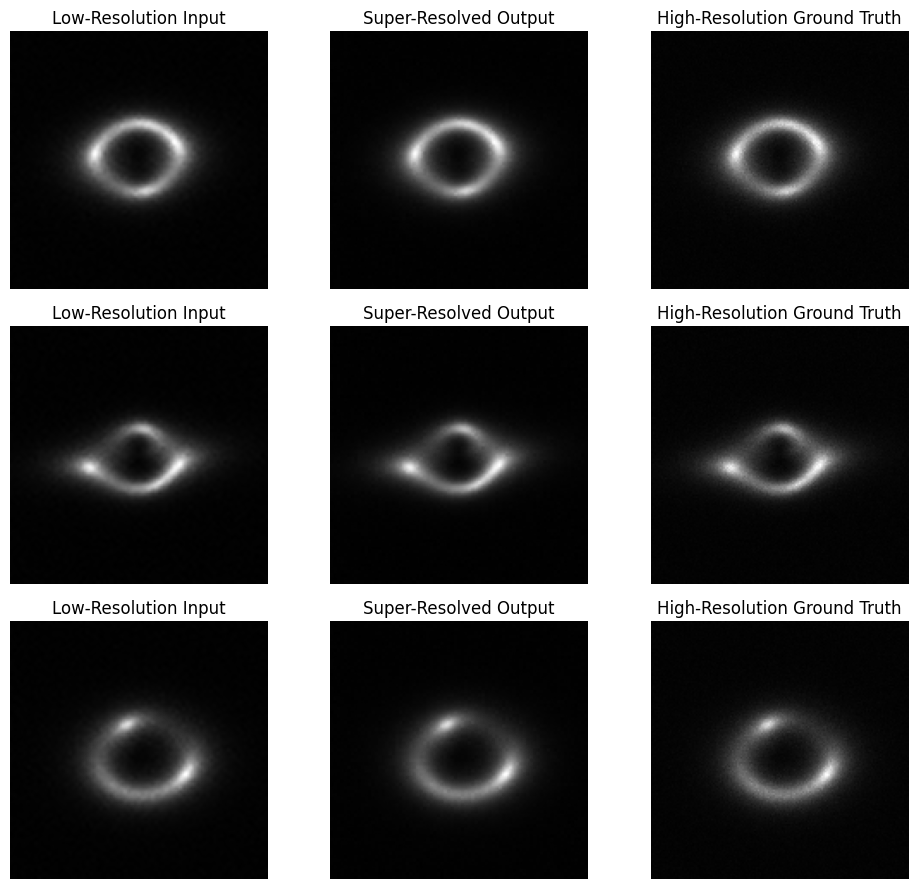

In [16]:
visualize_predictions(model, test_loader, num_samples=3)